<a href="https://colab.research.google.com/github/harjeetsingh22187-ai/Moving_Average_Demand_Forecasting/blob/main/Moving_Average_Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1 — Mount Google Drive in Colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Step 2 — Load dataset from Drive

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/ecommerce_customer_behavior_dataset.csv"

df = pd.read_csv(file_path)

df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


# Step 3 — Verify dataset loaded & Importing libraries

In [ ]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Date', 'Age', 'Gender', 'City',
       'Product_Category', 'Unit_Price', 'Quantity', 'Discount_Amount',
       'Total_Amount', 'Payment_Method', 'Device_Type',
       'Session_Duration_Minutes', 'Pages_Viewed', 'Is_Returning_Customer',
       'Delivery_Time_Days', 'Customer_Rating'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 4 — Convert Date column

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(by='Date')

# Step 5  — Aggregate daily demand

If dataset contains multiple records per day:

In [ ]:
daily_demand = df.groupby('Date')['Quantity'].sum().reset_index()

print(daily_demand.head())

        Date  Quantity
0 2023-01-01        18
1 2023-01-02        27
2 2023-01-03         6
3 2023-01-04        30
4 2023-01-05        31


# Step 6 — Choose moving average window


In [ ]:
window_size = 7

# Step 7 — Calculate moving average

In [ ]:
daily_demand['moving_avg'] = daily_demand['Quantity'].rolling(window=window_size).mean()

# Step 8 — Forecast future demand (important)

This creates realistic predictions.

In [ ]:
forecast_horizon = 30

history = daily_demand['Quantity'].tolist()

predictions = []

for i in range(forecast_horizon):

    next_value = sum(history[-window_size:]) / window_size

    predictions.append(next_value)

    history.append(next_value)

# Step 9 — Create future dates

In [ ]:
last_date = daily_demand['Date'].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_horizon
)

# Step 10 — Create forecast dataframe

In [ ]:
forecast_df = pd.DataFrame({

'Date': future_dates,

'Forecasted_Demand': predictions

})

# Step 11 — Save forecast data for backend

In [ ]:
daily_demand.to_csv("forecast_data.csv", index=False)

# Step 12 — Save model parameters

In [ ]:
model_params = {

"window_size": window_size,

"last_moving_avg": float(predictions[-1]),

"forecast_horizon": forecast_horizon

}

with open("model_params.json", "w") as f:

    json.dump(model_params, f)

# Step 13 — Plot graph for verification

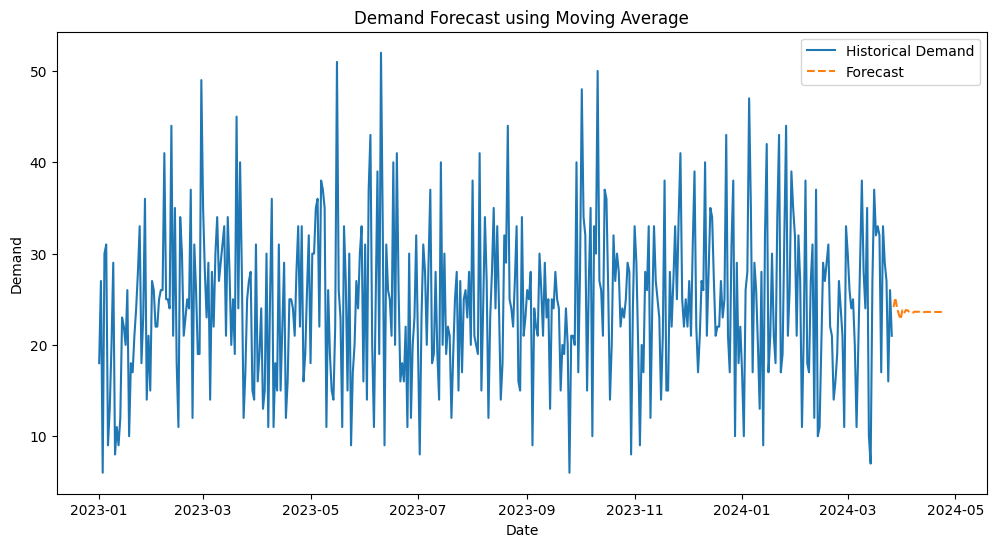

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(daily_demand['Date'], daily_demand['Quantity'], label="Historical Demand")

plt.plot(forecast_df['Date'], forecast_df['Forecasted_Demand'], label="Forecast", linestyle="--")

plt.legend()

plt.title("Demand Forecast using Moving Average")

plt.xlabel("Date")

plt.ylabel("Demand")

plt.show()

# Step 14 — Download files

In [ ]:
from google.colab import files

files.download("forecast_data.csv")

files.download("model_params.json")

# test the model with your own input values

# Step 1 — define your custom inputs

In [ ]:
initial_stock = 300
reorder_level = 120
lead_time = 7

Example:
You currently have 300 items in warehouse.

# Step 2 — combine historical + forecast demand

In [ ]:
combined_demand = list(daily_demand['Quantity']) + predictions

# Step 3 — simulate stock levels

In [ ]:
stock_levels = []

shortage_risk = []

current_stock = initial_stock

for demand in combined_demand:

    current_stock -= demand

    stock_levels.append(current_stock)

    shortage_risk.append(current_stock <= reorder_level)

# Step 4 — create result dataframe

In [ ]:
result_df = pd.DataFrame({

'Date': list(daily_demand['Date']) + list(future_dates),

'Demand': combined_demand,

'Stock_Level': stock_levels,

'Shortage_Risk': shortage_risk

})

# Step 5 — view results

In [ ]:
result_df.tail(15)

,Date,Demand,Stock_Level,Shortage_Risk
466,2024-04-11,23.614167,-11179.487263,True
467,2024-04-12,23.591067,-11203.078329,True
468,2024-04-13,23.592981,-11226.671310,True
469,2024-04-14,23.604680,-11250.275990,True
470,2024-04-15,23.614471,-11273.890461,True
471,2024-04-16,23.610887,-11297.501347,True
472,2024-04-17,23.609766,-11321.111114,True
473,2024-04-18,23.605431,-11344.716545,True
474,2024-04-19,23.604183,-11368.320728,True
475,2024-04-20,23.606057,-11391.926785,True


You will see:

future stock levels
where shortage happens

# Step 6 — calculate days until shortage

In [ ]:
days_until_shortage = next(

(i for i, risk in enumerate(shortage_risk) if risk),

None

)

print("Days until shortage:", days_until_shortage)

Days until shortage: 8


# Step 7 — plot simulation graph

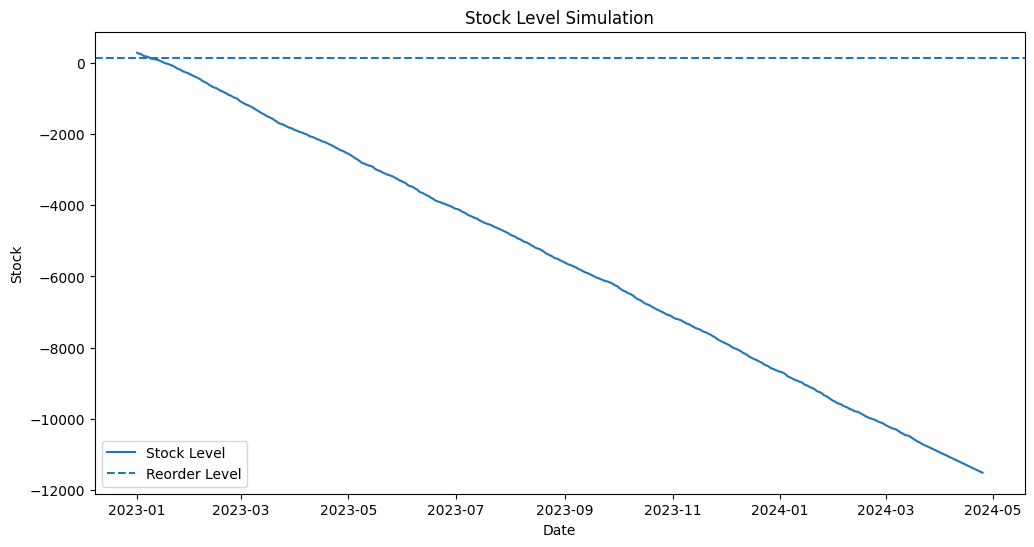

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(result_df['Date'], result_df['Stock_Level'], label="Stock Level")

plt.axhline(y=reorder_level, linestyle="--", label="Reorder Level")

plt.title("Stock Level Simulation")

plt.xlabel("Date")

plt.ylabel("Stock")

plt.legend()

plt.show()

# Step 8 — test different scenarios

Try different values:

Scenario 1 — low stock

In [ ]:
initial_stock = 100
reorder_level = 80

Scenario 2 — high demand risk

In [ ]:
initial_stock = 200
reorder_level = 150

Scenario 3 — safe inventory

In [ ]:
initial_stock = 800
reorder_level = 200